In [73]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import gurobipy as gp
from gurobipy import GRB
from pathlib import Path

## Loading datasets

In [74]:
products = pd.read_csv('../data/optimization/products.csv')
machines = pd.read_csv('../data/optimization/machines.csv')
routing = pd.read_csv('../data/optimization/routing.csv')
materials = pd.read_csv('../data/optimization/materials.csv')
bills = pd.read_csv('../data/optimization/bill_of_materials.csv')
availability = pd.read_csv('../data/optimization/machine_availability.csv')
forecast = pd.read_csv('../data/processed/forecasts/forecast.csv')

## Reconcile week numbering

In [75]:
forecast_weeks = sorted(forecast["week"].unique())
week_to_t = {week: t for t, week in enumerate(forecast_weeks, start=1)}

forecast["t"] = forecast["week"].map(week_to_t)
availability["t"] = availability["week"]  # already 1..12, relative planning weeks by construction

print(week_to_t)
assert forecast["t"].between(1, 12).all()
assert availability["t"].between(1, 12).all()

{np.int64(274): 1, np.int64(275): 2, np.int64(276): 3, np.int64(277): 4, np.int64(278): 5, np.int64(279): 6, np.int64(280): 7, np.int64(281): 8, np.int64(282): 9, np.int64(283): 10, np.int64(284): 11, np.int64(285): 12}


In [76]:
P = products["product_id"].tolist()
M = machines["machine_id"].tolist()
T = sorted(forecast["t"].unique().tolist())
R = materials["material_id"].tolist()
PM = list(routing[["product_id", "machine_id"]].itertuples(index=False, name=None))
idx_pmt = [(p, m, t) for (p, m) in PM for t in T]
print(f"{len(P)} products, {len(M)} machines, {len(T)} periods, {len(R)} materials, {len(idx_pmt)} (p,m,t) triples")

10 products, 6 machines, 12 periods, 13 materials, 240 (p,m,t) triples


## Parameters

In [77]:
OVERTIME_WAGE_PER_HOUR = 35  # $ per operator-hour

overtime_cost_per_hour = {
    row.machine_id: OVERTIME_WAGE_PER_HOUR * row.labor_requirement
    for row in machines.itertuples()
}
overtime_hours = machines.set_index("machine_id")["overtime_hours"].to_dict()

availability_fraction = machines.set_index("machine_id")["availability"].to_dict()

available_hours = {
    (row.machine_id, row.t): row.available_hours * availability_fraction[row.machine_id]
    for row in availability.itertuples()
}

print("overtime_cost_per_hour:", overtime_cost_per_hour)
print("example available_hours (M01, t=1):", available_hours[("M01", 1)])

overtime_cost_per_hour: {'M01': 105, 'M02': 70, 'M03': 70, 'M04': 70, 'M05': 35, 'M06': 35}
example available_hours (M01, t=1): 58.199999999999996


In [78]:
production_cost = products.set_index("product_id")["production_cost"].to_dict()
holding_cost = products.set_index("product_id")["holding_cost"].to_dict()
shortage_cost = products.set_index("product_id")["shortage_cost"].to_dict()
max_inventory = products.set_index("product_id")["max_inventory"].to_dict()
safety_stock = products.set_index("product_id")["safety_stock"].to_dict()

initial_inventory = products.set_index("product_id")["safety_stock"].to_dict()

demand = {(row.product_id, row.t): row.forecast for row in forecast.itertuples()}

print("example demand (P01, t=1):", demand[("P01", 1)])
print("example initial_inventory (P01):", initial_inventory["P01"])

example demand (P01, t=1): 3024.4
example initial_inventory (P01): 504


In [79]:
processing_time = {(row.product_id, row.machine_id): row.processing_time for row in routing.itertuples()}

material_availability = materials.set_index("material_id")["availability"].to_dict()
material_qty = {(row.product_id, row.material_id): row.quantity_required for row in bills.itertuples()}

print("example processing_time (P01, M01):", processing_time[("P01", "M01")])
print("example material_availability (RM01):", material_availability["RM01"])

example processing_time (P01, M01): 0.02
example material_availability (RM01): 2425


## Build the model

Decision variables:
- `x[p,m,t]` : production quantity, only for valid `(p,m)` routing pairs
- `inv[p,t]` : end-of-period inventory
- `shortage[p,t]` : unmet demand
- `overtime[m,t]` : overtime hours used, bounded by `overtime_hours[m]`

In [80]:
model = gp.Model("production_planning_lp")
model.Params.OutputFlag = 0

In [81]:
x = model.addVars(idx_pmt, lb=0, name="x")
inv = model.addVars(P, T, lb=0, name="inv")
shortage = model.addVars(P, T, lb=0, name="shortage")
overtime = model.addVars(M, T, lb=0, name="overtime")
for m in M:
    for t in T:
        overtime[m, t].UB = overtime_hours[m]

## Constraints

In [82]:
# Inventory balance: previous inventory + this period's production = demand - shortage + ending inventory
model.addConstrs(
    (
        (initial_inventory[p] if t == T[0] else inv[p, t - 1])
        + gp.quicksum(x[p, m, t] for m in M if (p, m) in PM)
        == demand[p, t] - shortage[p, t] + inv[p, t]
        for p in P for t in T
    ),
    name="inventory_balance",
)

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [83]:
# Storage cap
model.addConstrs((inv[p, t] <= max_inventory[p] for p in P for t in T), name="max_inventory")

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [84]:
# Safety stock as a hard floor: inv[p,t] >= safety_stock[p]. Combined with initial_inventory
model.addConstrs((inv[p, t] >= safety_stock[p] for p in P for t in T), name="safety_stock")

{('P01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('P01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('P02', 7): <gurobi.Cons

In [85]:
# Machine capacity: processing time used <= regular effective hours + overtime used
model.addConstrs(
    (
        gp.quicksum(processing_time[p, m] * x[p, m, t] for p in P if (p, m) in PM)
        <= available_hours[m, t] + overtime[m, t]
        for m in M for t in T
    ),
    name="machine_capacity",
)

{('M01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('M01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('M02', 7): <gurobi.Cons

In [86]:
# Material: total consumption across all products/machines <= weekly availability
model.addConstrs(
    (
        gp.quicksum(
            material_qty[p, r] * gp.quicksum(x[p, m, t] for m in M if (p, m) in PM)
            for p in P if (p, r) in material_qty
        )
        <= material_availability[r]
        for r in R for t in T
    ),
    name="material",
)

{('RM01', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 7): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 8): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 9): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 10): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 11): <gurobi.Constr *Awaiting Model Update*>,
 ('RM01', 12): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 1): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 2): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 3): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 4): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 5): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02', 6): <gurobi.Constr *Awaiting Model Update*>,
 ('RM02

## Objective

Minimize production + holding + overtime + shortage cost

In [87]:
model.setObjective(
    gp.quicksum(production_cost[p] * x[p, m, t] for (p, m) in PM for t in T)
    + gp.quicksum(holding_cost[p] * inv[p, t] for p in P for t in T)
    + gp.quicksum(overtime_cost_per_hour[m] * overtime[m, t] for m in M for t in T)
    + gp.quicksum(shortage_cost[p] * shortage[p, t] for p in P for t in T),
    GRB.MINIMIZE,
)

## Solve

In [88]:
start = time.time()
model.optimize()
solve_time_a = time.time() - start

print("status:", model.Status, "(2 = OPTIMAL)")
print("total cost:", round(model.ObjVal, 2))
print("solve time: %.3fs" % solve_time_a)

status: 2 (2 = OPTIMAL)
total cost: 72878.47
solve time: 0.013s


## Extract results

In [89]:
production_plan = pd.DataFrame([
    {"product_id": p, "machine_id": m, "t": t, "quantity": x[p, m, t].X}
    for (p, m) in PM for t in T
])
production_plan = production_plan[production_plan["quantity"] > 1e-6].round({"quantity": 1})
production_plan = production_plan.sort_values(["product_id", "t"]).reset_index(drop=True)

print("production rows (nonzero):", len(production_plan))
production_plan.head(15)

production rows (nonzero): 161


,product_id,machine_id,t,quantity
0,P01,M01,1,2910.0
1,P01,M02,1,114.4
2,P01,M01,2,1021.7
3,P01,M02,2,2105.1
4,P01,M01,3,948.7
5,P01,M02,3,2165.4
6,P01,M01,4,841.7
7,P01,M02,4,2275.5
8,P01,M01,5,985.7
9,P01,M02,5,2177.7


In [90]:
inventory_plan = pd.DataFrame([
    {"product_id": p, "t": t, "inventory": inv[p, t].X}
    for p in P for t in T
]).round({"inventory": 1})

inventory_plan["safety_stock"] = inventory_plan["product_id"].map(safety_stock)
inventory_plan["below_safety_stock"] = inventory_plan["inventory"] < inventory_plan["safety_stock"]

print("product-weeks below safety stock:", inventory_plan["below_safety_stock"].sum(), "/", len(inventory_plan))
inventory_plan[inventory_plan["below_safety_stock"]]

product-weeks below safety stock: 0 / 120


,product_id,t,inventory,safety_stock,below_safety_stock


In [91]:
shortage_report = pd.DataFrame([
    {"product_id": p, "t": t, "shortage": shortage[p, t].X}
    for p in P for t in T
])
shortage_report = shortage_report[shortage_report["shortage"] > 1e-6].round({"shortage": 1})

print("shortage rows (nonzero):", len(shortage_report))
shortage_report

shortage rows (nonzero): 0


,product_id,t,shortage


In [92]:
overtime_usage = pd.DataFrame([
    {"machine_id": m, "t": t, "overtime_hours_used": overtime[m, t].X}
    for m in M for t in T
])
overtime_usage = overtime_usage[overtime_usage["overtime_hours_used"] > 1e-6].round({"overtime_hours_used": 1})

print("machine-weeks using overtime:", len(overtime_usage))
overtime_usage

machine-weeks using overtime: 0


,machine_id,t,overtime_hours_used


## Cost breakdown

Recompute each objective term's solved value separately, to see where the total cost actually
comes from rather than just the aggregate.

In [93]:
cost_breakdown = {
    "production": sum(production_cost[p] * x[p, m, t].X for (p, m) in PM for t in T),
    "holding": sum(holding_cost[p] * inv[p, t].X for p in P for t in T),
    "overtime": sum(overtime_cost_per_hour[m] * overtime[m, t].X for m in M for t in T),
    "shortage": sum(shortage_cost[p] * shortage[p, t].X for p in P for t in T),
}

cost_breakdown_df = pd.Series(cost_breakdown).rename("cost").to_frame()
cost_breakdown_df["share_pct"] = (cost_breakdown_df["cost"] / cost_breakdown_df["cost"].sum() * 100).round(1)

print("sum of terms:   ", round(sum(cost_breakdown.values()), 2))
print("objective value:", round(model.ObjVal, 2))
cost_breakdown_df.round(2)

sum of terms:    72878.47
objective value: 72878.47


,cost,share_pct
production,72488.50,99.5
holding,389.96,0.5
overtime,0.00,0.0
shortage,0.00,0.0


## Sanity check: accounting identity

For each product: `initial_inventory + total_production == total_demand - total_shortage + ending_inventory`.
Should hold to numerical tolerance if the inventory balance constraint is correctly formulated.

In [94]:
check_rows = []
for p in P:
    total_production = sum(x[p, m, t].X for m in M if (p, m) in PM for t in T)
    total_demand = sum(demand[p, t] for t in T)
    total_shortage = sum(shortage[p, t].X for t in T)
    ending_inv = inv[p, T[-1]].X

    lhs = initial_inventory[p] + total_production
    rhs = total_demand - total_shortage + ending_inv
    check_rows.append((p, lhs, rhs, abs(lhs - rhs)))

check_df = pd.DataFrame(check_rows, columns=["product_id", "lhs", "rhs", "diff"])
print("max diff across products:", check_df["diff"].max())
check_df.round(3)

max diff across products: 0.0


,product_id,lhs,rhs,diff
0,P01,40039.5,40039.5,0.0
1,P02,8840.9,8840.9,0.0
2,P03,635.6,635.6,0.0
3,P04,283.7,283.7,0.0
4,P05,4502.7,4502.7,0.0
5,P06,581.2,581.2,0.0
6,P07,290.7,290.7,0.0
7,P08,5051.4,5051.4,0.0
8,P09,433.2,433.2,0.0
9,P10,280.5,280.5,0.0


## Visualization: production vs forecast demand, per product

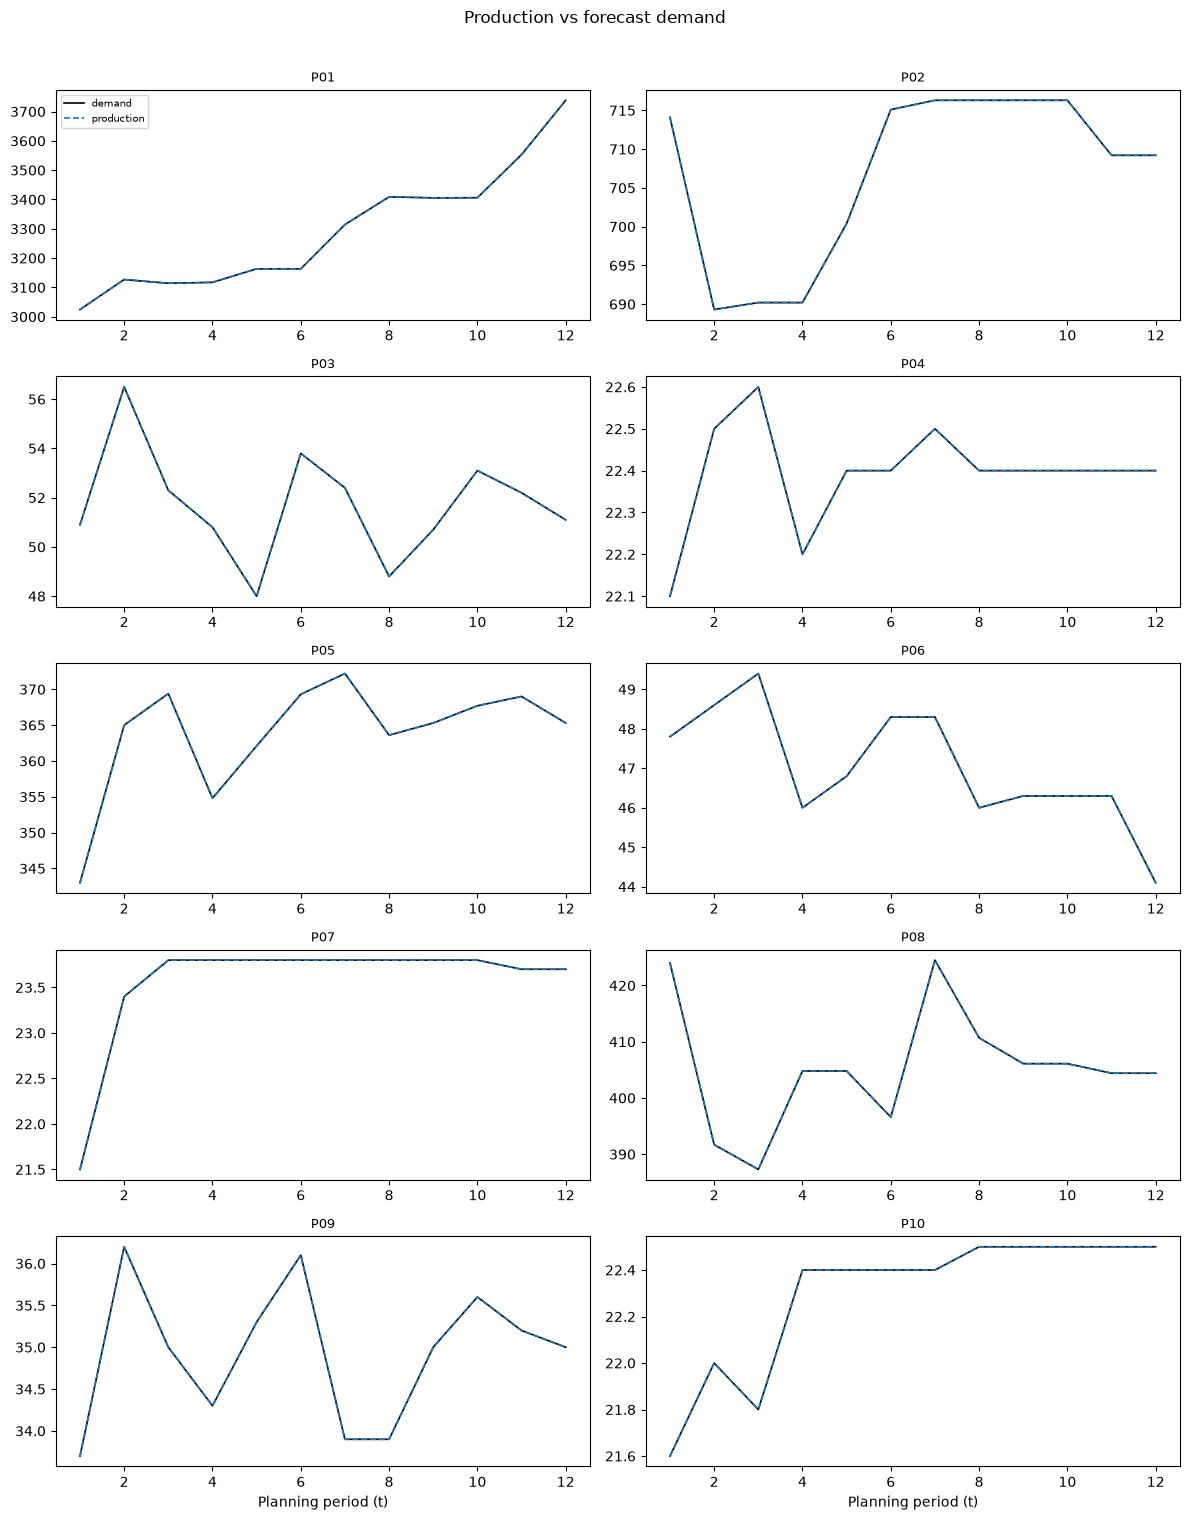

In [95]:
weekly_production = production_plan.groupby(["product_id", "t"])["quantity"].sum().reset_index()

fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    dem = forecast[forecast["product_id"] == p].sort_values("t")
    prod = weekly_production[weekly_production["product_id"] == p]

    ax.plot(dem["t"], dem["forecast"], color="black", linewidth=1.2, label="demand")
    ax.plot(prod["t"], prod["quantity"], color="tab:blue", linestyle="--", linewidth=1.2, label="production")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Production vs forecast demand", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: inventory trajectory, per product

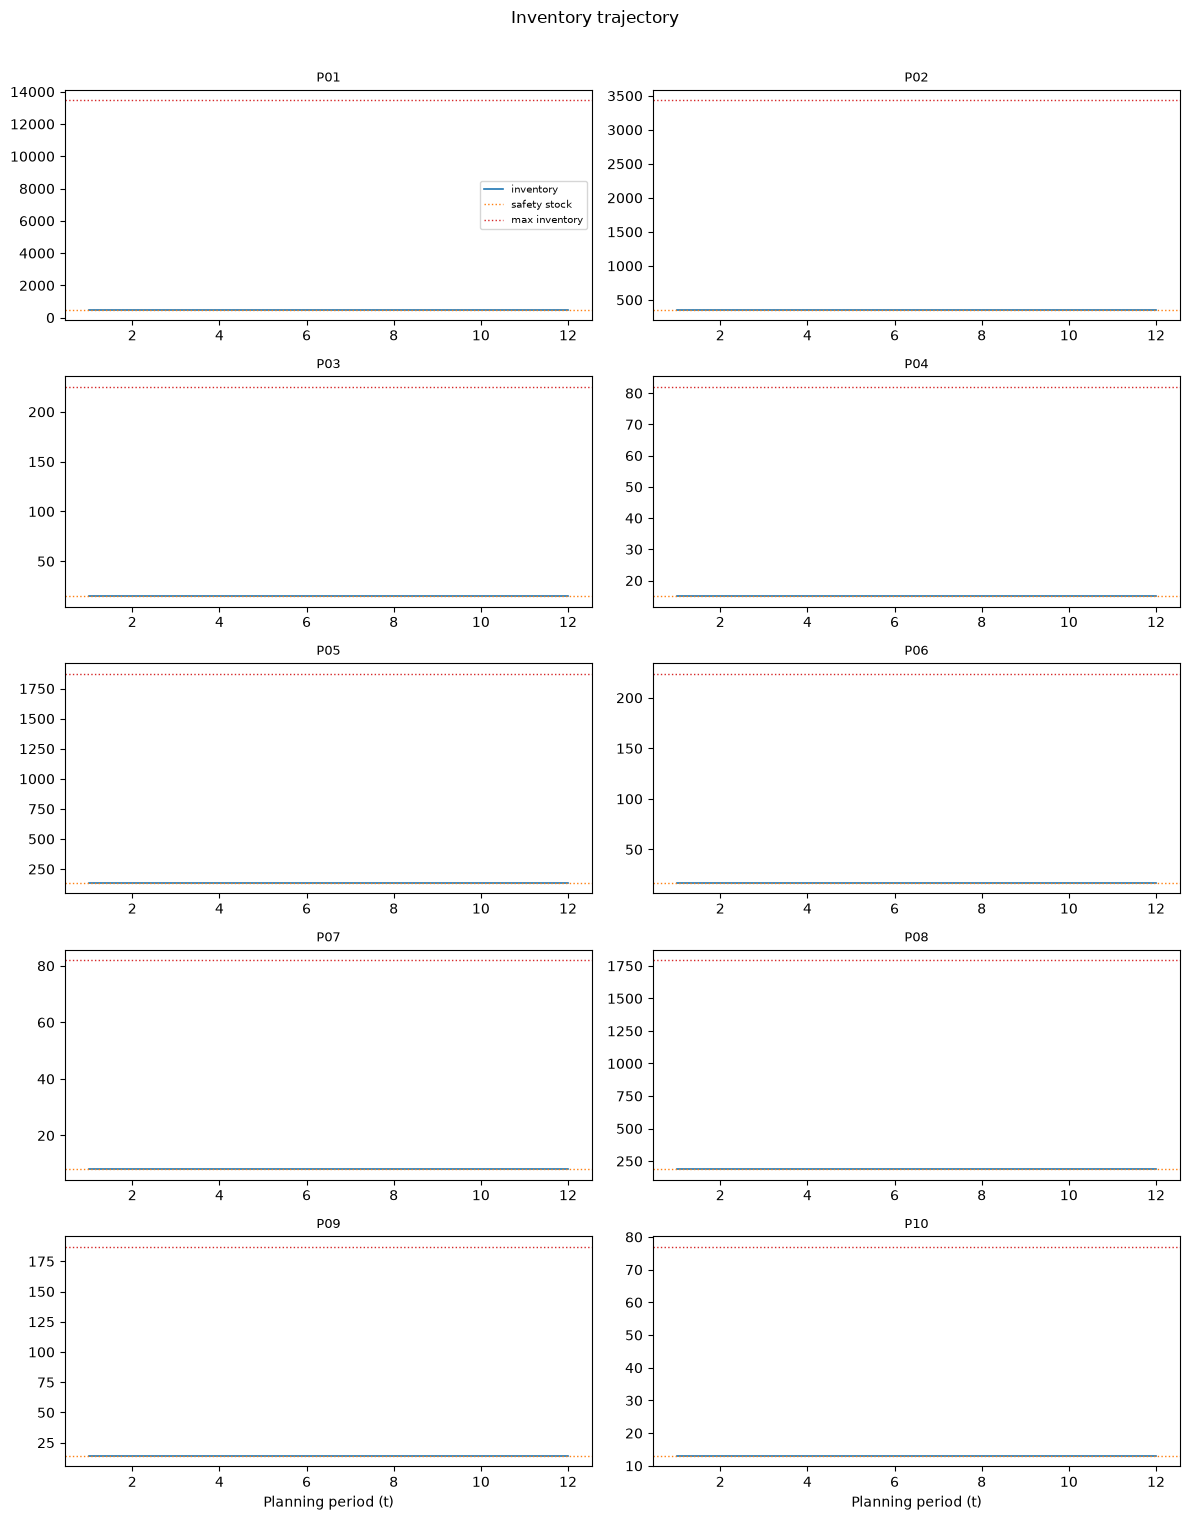

In [96]:
fig, axes = plt.subplots(5, 2, figsize=(12, 15), sharex=False)

for ax, p in zip(axes.flat, P):
    inv = inventory_plan[inventory_plan["product_id"] == p].sort_values("t")

    ax.plot(inv["t"], inv["inventory"], color="tab:blue", linewidth=1.2, label="inventory")
    ax.axhline(safety_stock[p], color="tab:orange", linestyle=":", linewidth=1, label="safety stock")
    ax.axhline(max_inventory[p], color="tab:red", linestyle=":", linewidth=1, label="max inventory")
    ax.set_title(p, fontsize=9)

axes.flat[0].legend(fontsize=7)
for ax in axes[-1]:
    ax.set_xlabel("Planning period (t)")

fig.suptitle("Inventory trajectory", y=1.01)
fig.tight_layout()
plt.show()

## Visualization: machine utilization

% of *regular* effective hours used by processing time (can exceed 100% when overtime is used).

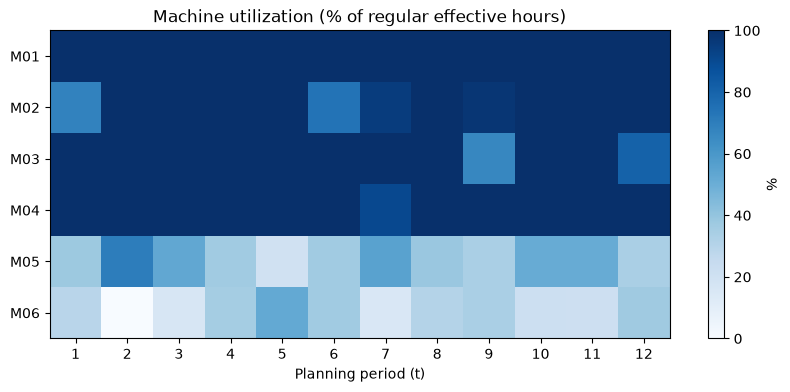

t,1,2,3,4,5,6,7,8,9,10,11,12
machine_id,,,,,,,,,,,,
M01,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0
M02,68.3,100.0,100.0,100.0,100.0,74.0,95.1,100.0,97.3,100.0,100.0,100.0
M03,100.0,100.0,100.0,100.0,100.0,100.0,100.0,100.0,66.7,100.0,100.0,80.5
M04,100.0,100.0,100.0,100.0,100.0,100.0,90.5,100.0,100.0,100.0,100.0,100.0
M05,37.6,70.3,52.8,36.6,19.6,36.6,55.4,38.5,33.7,50.9,50.8,33.9
M06,29.1,0.0,15.9,35.5,52.1,36.7,15.0,30.8,33.7,21.5,21.2,36.9


In [97]:
production_plan["hours"] = production_plan.apply(
    lambda r: processing_time[(r["product_id"], r["machine_id"])] * r["quantity"], axis=1
)
used_hours = production_plan.groupby(["machine_id", "t"])["hours"].sum().reset_index()

util = pd.DataFrame([(m, t) for m in M for t in T], columns=["machine_id", "t"])
util = util.merge(used_hours, on=["machine_id", "t"], how="left").fillna({"hours": 0})
util["available_hours"] = util.apply(lambda r: available_hours[(r["machine_id"], r["t"])], axis=1)
util["utilization_pct"] = (util["hours"] / util["available_hours"] * 100).round(1)

pivot_util = util.pivot(index="machine_id", columns="t", values="utilization_pct").reindex(M)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(pivot_util.values, aspect="auto", cmap="Blues", vmin=0)
ax.set_yticks(range(len(pivot_util.index)))
ax.set_yticklabels(pivot_util.index)
ax.set_xticks(range(len(pivot_util.columns)))
ax.set_xticklabels(pivot_util.columns)
ax.set_xlabel("Planning period (t)")
ax.set_title("Machine utilization (% of regular effective hours)")
fig.colorbar(im, ax=ax, label="%")
plt.show()

pivot_util

## Save results

For notebook 06 to load and compare against, instead of rebuilding Model A from scratch there.

In [98]:
RESULTS_DIR = Path("../results/tables")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [99]:
production_plan.to_csv(RESULTS_DIR / "model_a_production_plan.csv", index=False)
inventory_plan.to_csv(RESULTS_DIR / "model_a_inventory_plan.csv", index=False)
shortage_report.to_csv(RESULTS_DIR / "model_a_shortage_report.csv", index=False)
overtime_usage.to_csv(RESULTS_DIR / "model_a_overtime_usage.csv", index=False)
cost_breakdown_df.to_csv(RESULTS_DIR / "model_a_cost_breakdown.csv")

In [100]:

machine_usage_a = production_plan.groupby("machine_id")["hours"].sum().reindex(M, fill_value=0)
machine_usage_a.to_csv(RESULTS_DIR / "model_a_machine_usage.csv", header=["total_hours"])

In [101]:
summary_a = pd.DataFrame([{
    "model": "Model A (LP, no setup)",
    "status": model.Status,
    "total_cost": model.ObjVal,
    "solve_time_s": solve_time_a,
}])
summary_a.to_csv(RESULTS_DIR / "model_a_summary.csv", index=False)

print("Saved Model A results to", RESULTS_DIR.resolve())

Saved Model A results to C:\Users\HP\Walid\Industrial_production_optimization\results\tables


## Baseline: conventional strategy

Simple rule based plan, not optimized. Produce to demand, fixed primary machine per product, top up to safety stock, use overtime only if regular hours run out.

In [102]:
# primary machine per product, lowest setup cost option
primary_machine = routing.loc[routing.groupby("product_id")["setup_cost"].idxmin()]
primary_machine = primary_machine.set_index("product_id")["machine_id"].to_dict()
primary_machine

{'P01': 'M01',
 'P02': 'M02',
 'P03': 'M03',
 'P04': 'M05',
 'P05': 'M03',
 'P06': 'M04',
 'P07': 'M06',
 'P08': 'M04',
 'P09': 'M05',
 'P10': 'M06'}

In [103]:
# order up to safety stock, fixed machine, overtime only if short on regular hours
baseline_inv = dict(initial_inventory)
prod_rows = []
inv_rows = []
shortage_rows = []
overtime_rows = []

for t in T:
    hours_left = {m: available_hours[m, t] for m in M}
    ot_left = {m: overtime_hours[m] for m in M}
    for p in P:
        m = primary_machine[p]
        rate = processing_time[p, m]
        target = max(demand[p, t] + safety_stock[p] - baseline_inv[p], 0)
        hours_needed = target * rate

        reg = min(hours_needed, hours_left[m])
        ot = min(hours_needed - reg, ot_left[m])
        hours_left[m] -= reg
        ot_left[m] -= ot
        produced = (reg + ot) / rate
        prod_rows.append((p, m, t, produced))
        if ot > 1e-9:
            overtime_rows.append((m, t, ot))

        end_inv = baseline_inv[p] + produced - demand[p, t]
        if end_inv < 0:
            shortage_rows.append((p, t, -end_inv))
            end_inv = 0
        end_inv = min(end_inv, max_inventory[p])
        inv_rows.append((p, t, end_inv))
        baseline_inv[p] = end_inv

In [104]:
baseline_production = pd.DataFrame(prod_rows, columns=["product_id", "machine_id", "t", "quantity"])
baseline_production = baseline_production[baseline_production["quantity"] > 1e-6].round({"quantity": 1})
baseline_production.head(15)

,product_id,machine_id,t,quantity
0,P01,M01,1,3024.4
1,P02,M02,1,714.1
2,P03,M03,1,50.9
3,P04,M05,1,22.1
4,P05,M03,1,343.0
5,P06,M04,1,47.8
6,P07,M06,1,21.5
7,P08,M04,1,424.0
8,P09,M05,1,33.7
9,P10,M06,1,21.6


In [105]:
baseline_inventory = pd.DataFrame(inv_rows, columns=["product_id", "t", "inventory"]).round({"inventory": 1})
baseline_inventory["safety_stock"] = baseline_inventory["product_id"].map(safety_stock)
baseline_inventory["below_safety_stock"] = baseline_inventory["inventory"] < baseline_inventory["safety_stock"]

print("below safety stock:", baseline_inventory["below_safety_stock"].sum(), "/", len(baseline_inventory))

below safety stock: 0 / 120


In [106]:
baseline_shortage = pd.DataFrame(shortage_rows, columns=["product_id", "t", "shortage"]).round({"shortage": 1})
print("shortage rows:", len(baseline_shortage))
baseline_shortage

shortage rows: 0


,product_id,t,shortage


In [107]:
baseline_overtime = pd.DataFrame(overtime_rows, columns=["machine_id", "t", "overtime_hours_used"])
baseline_overtime = baseline_overtime.groupby(["machine_id", "t"], as_index=False)["overtime_hours_used"].sum().round(1)
print("overtime rows:", len(baseline_overtime))
baseline_overtime

overtime rows: 36


,machine_id,t,overtime_hours_used
0,M01,1,2.3
1,M01,2,4.3
2,M01,3,4.1
3,M01,4,4.1
4,M01,5,5.1
5,M01,6,5.1
6,M01,7,8.1
7,M01,8,10.0
8,M01,9,9.9
9,M01,10,9.9


In [108]:
baseline_cost = {
    "production": sum(production_cost[p] * q for (p, m, t, q) in prod_rows),
    "holding": sum(holding_cost[p] * v for (p, t, v) in inv_rows),
    "overtime": sum(overtime_cost_per_hour[m] * h for (m, t, h) in overtime_rows),
    "shortage": sum(shortage_cost[p] * s for (p, t, s) in shortage_rows),
}
baseline_cost_df = pd.Series(baseline_cost).rename("cost").to_frame()
baseline_cost_df["share_pct"] = (baseline_cost_df["cost"] / baseline_cost_df["cost"].sum() * 100).round(1)
baseline_total_cost = sum(baseline_cost.values())

print("baseline total cost:", round(baseline_total_cost, 2))
baseline_cost_df.round(2)

baseline total cost: 100978.64


,cost,share_pct
production,72488.50,71.8
holding,389.96,0.4
overtime,28100.17,27.8
shortage,0.00,0.0


In [109]:
baseline_production.to_csv(RESULTS_DIR / "baseline_production_plan.csv", index=False)
baseline_inventory.to_csv(RESULTS_DIR / "baseline_inventory_plan.csv", index=False)
baseline_shortage.to_csv(RESULTS_DIR / "baseline_shortage_report.csv", index=False)
baseline_overtime.to_csv(RESULTS_DIR / "baseline_overtime_usage.csv", index=False)
baseline_cost_df.to_csv(RESULTS_DIR / "baseline_cost_breakdown.csv")

In [110]:
baseline_summary = pd.DataFrame([{
    "model": "Baseline (conventional)",
    "total_cost": baseline_total_cost,
}])
baseline_summary.to_csv(RESULTS_DIR / "baseline_summary.csv", index=False)

print("Saved baseline results to", RESULTS_DIR.resolve())

Saved baseline results to C:\Users\HP\Walid\Industrial_production_optimization\results\tables


## Compare baseline vs Model A

In [111]:
terms = ["production", "holding", "overtime", "shortage"]
comparison = pd.DataFrame({
    "Baseline": baseline_cost_df["cost"].reindex(terms),
    "Model A": cost_breakdown_df["cost"].reindex(terms),
})
comparison.loc["TOTAL"] = [baseline_total_cost, model.ObjVal]
comparison.round(2)

,Baseline,Model A
production,72488.50,72488.50
holding,389.96,389.96
overtime,28100.17,0.00
shortage,0.00,0.00
TOTAL,100978.64,72878.47


In [112]:
reduction_pct = (1 - model.ObjVal / baseline_total_cost) * 100
print("cost reduction from optimization:", round(reduction_pct, 1), "%")

cost reduction from optimization: 27.8 %
